# Purpose:
- Running another round of landmark extension.
- Based on the 1st iteration, where no GFP threshold was used.
    - Now set the threshold based on QC'ed ROIs.
    - Now simply use distance matrix. Don't iterate, make one matrix, and match all at once.
        - This reduces mismatching between nearby cells.
- Metrics:
    - How many more co-registered cells after another iteration?
    - How much does additional manual step help?
# Protocol:
- Filter HCR data based on spot counts and density
- Find nearest matches (greedy method)


In [1]:
import os
import zarr
import numpy as np
import tifffile as tiff
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import Rbf
from scipy.spatial import distance_matrix
import cv2
import os
import json
from pathlib import Path

DATA_DIR = Path('/root/capsule/data/')

%load_ext autoreload
%autoreload 2

In [2]:
def get_ids_from_landmarks(landmarks):
    columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
    assert len(landmarks.columns) == len(columns)
    if not all([a==b for a,b in zip(landmarks.columns, columns)]):
        landmarks.columns = columns
    matched_ids = landmarks['ids'].values
    def _get_ids(x):
        if x.startswith('cz'):
            cz_id = int(x.split('-')[0].split('cz')[-1])
            hcr_id = int(x.split('-')[1].split('hcr')[-1])
            return cz_id, hcr_id
        else:
            return -1
    
    ids = [_get_ids(x) for x in matched_ids]
    ids = [id for id in ids if id != -1]
    zstack_ids = [id[0] for id in ids]
    hcr_ids = [id[1] for id in ids]
    return zstack_ids, hcr_ids

In [3]:
subject_id = 767022
save_dir = Path('/root/capsule/scratch/767022_2025-03-06_coreg_cpsam/')
filepaths_json = save_dir / '767022_2025-03-06_filepaths.json'
with open(filepaths_json, 'r') as f:
    filepaths_dict = json.load(f)
for key in filepaths_dict:
    filepaths_dict[key] = Path(filepaths_dict[key])
    assert filepaths_dict[key].exists()
print(filepaths_dict.keys())
# make variables named after each filepath
for key in filepaths_dict:
    globals()[key] = filepaths_dict[key]
hcr_dir = fused_json_file.parent

dict_keys(['czstack_reg_path', 'czstack_reg_dim_swapped_path', 'czstack_seg_path', 'czstack_seg_outline_path', 'czstack_centroid_path', 'hcr_centroid_path', 'fused_json_file'])


# Repeat data loading as in 1st_iter

In [5]:
# Find spot data
spots_488_path = hcr_dir / 'image_spot_detection/channel_488_spots/spots.csv'
if spots_488_path.exists():
    spots_488 = pd.read_csv(spots_488_path)
    spot_488_counts = pd.DataFrame(spots_488['SEG_ID'].value_counts())
    spot_488_counts.rename(columns={'SEG_ID': 'hcr_id'}, inplace=True)
    spot_488_bounding_box_min = spots_488.groupby('SEG_ID').agg({'X':'min','Y':'min','Z':'min'}).rename(columns={'X':'min_x','Y':'min_y','Z':'min_z'})
    spot_488_bounding_box_max = spots_488.groupby('SEG_ID').agg({'X':'max','Y':'max','Z':'max'}).rename(columns={'X':'max_x','Y':'max_y','Z':'max_z'})
    spot_488_bounding_box = pd.concat([spot_488_bounding_box_min, spot_488_bounding_box_max], axis=1)
    spot_488_bounding_box['bb_volume'] = (spot_488_bounding_box['max_x'] - spot_488_bounding_box['min_x'] + 1) * (spot_488_bounding_box['max_y'] - spot_488_bounding_box['min_y'] + 1) * (spot_488_bounding_box['max_z'] - spot_488_bounding_box['min_z'] + 1)
    spot_488_counts = spot_488_counts.merge(spot_488_bounding_box[['bb_volume']], left_index=True, right_index=True)
    spot_488_counts['density'] = spot_488_counts['count'] / spot_488_counts['bb_volume']
    spot_488_counts.set_index('hcr_id', inplace=True)
else:
    spots_path = DATA_DIR / f'cell_data_mean_{subject_id}_R1.csv'
    assert spots_path.exists(), f'No spot_depetection processing nor {spots_path} for {subject_id}'
    spot_488_counts = pd.read_csv(spots_path).query('channel==488')
    spot_488_counts.rename(columns={'cell_id': 'hcr_id', 'mean': 'density'}, inplace=True)
    spot_488_counts.set_index('hcr_id', inplace=True)


# Get HCR centroid and scales
with open(fused_json_file, 'r') as file:
    data = json.load(file)
scale_x = data['dimensions']['x'][0]*4e6
scale_y = data['dimensions']['y'][0]*4e6
scale_z = data['dimensions']['z'][0]*1e6

HCR_cell_centroids = np.load(hcr_centroid_path)

HCR_cell_ids = HCR_cell_centroids[:,3]
HCR_cell_centroids = HCR_cell_centroids[:,:-1]

HCR_cell_centroids_df = pd.DataFrame()
HCR_cell_centroids_df['hcr_cell_id'] = HCR_cell_ids
HCR_cell_centroids_df['hcr_z'] = HCR_cell_centroids[:,0]
HCR_cell_centroids_df['hcr_y'] = HCR_cell_centroids[:,1]
HCR_cell_centroids_df['hcr_x'] = HCR_cell_centroids[:,2]
HCR_cell_centroids_df.set_index('hcr_cell_id', inplace=True)


# Get cortical z-stack centroids
czstack_cell_centroids_df = pd.read_csv(czstack_centroid_path, index_col=0)


## Get landmarks from the previous iteration
- Get previously matched IDs
- Apply transformation

In [15]:
# Get landmarks from the previous iteration
current_iter = 2
prev_iter = current_iter - 1
landmarks_file = next(save_dir.glob(f'{subject_id}_landmarks_matched_ext_iter{prev_iter}.csv'))
# landmarks_file = next(save_dir.glob(f'{subject_id}_landmarks_matched_ext_iter{prev_iter}_reordered_qced.csv'))

landmarks = pd.read_csv(landmarks_file,header=None)
columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
landmarks.columns = columns
num_roi_points = sum(landmarks.ids.str.startswith('cz'))
landmarks = landmarks.query('active')

points_zstack = landmarks[['czstack_x', 'czstack_y', 'czstack_z']].values.astype(np.float32)
points_HCR = landmarks[['hcr_x', 'hcr_y', 'hcr_z']].values.astype(np.float32)

matched_czstack_ids, matched_hcr_ids = get_ids_from_landmarks(landmarks)
leftover_czstack_ids = list(set(czstack_cell_centroids_df.index) - set(matched_czstack_ids))
leftover_czstack_df = czstack_cell_centroids_df.loc[leftover_czstack_ids]
leftover_czstack_cell_centroids = np.vstack(leftover_czstack_df[['czstack_x','czstack_y','czstack_z']].values)

interp_zstacktoHCR_0 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,0],
                           function='thin_plate')
interp_zstacktoHCR_1 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,1],
                           function='thin_plate')
interp_zstacktoHCR_2 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,2],
                           function='thin_plate')

HCR_centroids_est = np.zeros_like(leftover_czstack_cell_centroids)

HCR_centroids_est[:,0] = interp_zstacktoHCR_0(leftover_czstack_cell_centroids[:, 0],
                                              leftover_czstack_cell_centroids[:, 1],
                                              leftover_czstack_cell_centroids[:, 2]) / scale_x
HCR_centroids_est[:,1] = interp_zstacktoHCR_1(leftover_czstack_cell_centroids[:, 0],
                                              leftover_czstack_cell_centroids[:, 1],
                                              leftover_czstack_cell_centroids[:, 2]) / scale_y
HCR_centroids_est[:,2] = interp_zstacktoHCR_2(leftover_czstack_cell_centroids[:, 0],
                                              leftover_czstack_cell_centroids[:, 1],
                                              leftover_czstack_cell_centroids[:, 2]) / scale_z

print(f'{len(matched_czstack_ids)} matched in the previous iteration {prev_iter} out of total {num_roi_points} ROIs.')
print(f'{(len(matched_czstack_ids) / num_roi_points)*100:.2f} %')

119 matched in the previous iteration 1 out of total 926 ROIs.
12.85 %


# Estimating based on GFP count after filtering
- Picking the nearest HCR segmentation
- filtering based on the matched cells in the previous round

In [8]:
# filtering
matched_spot_counts = spot_488_counts.loc[matched_hcr_ids]
nonmatched_spot_counts = spot_488_counts.drop(index=matched_hcr_ids)

filter_rate = 0.9

min_counts = matched_spot_counts['count'].min() * filter_rate
min_density = matched_spot_counts['density'].min() * filter_rate
leftover_spot_counts = nonmatched_spot_counts.query('count >= @min_counts and density >= @min_density')

leftover_HCR_df = pd.merge(leftover_spot_counts, HCR_cell_centroids_df, left_index=True, right_index=True, how='inner')


In [9]:
# One-to-One Matching Algorithm
# Solves the many-to-one problem by iteratively assigning best matches

def one_to_one_matching(dist_matrix):
    """
    Solve one-to-one matching from distance matrix.
    
    Parameters:
    -----------
    dist_matrix : ndarray of shape (M, N)
        Distance matrix where M is number of source points (HCR_centroids_est)
        and N is number of target points (hcr_centroids)
    
    Returns:
    --------
    matched_indices : ndarray of shape (M,)
        Index of matched target point for each source point (-1 if unmatched)
    matched_distances : ndarray of shape (M,)
        Distance to matched target point for each source point (inf if unmatched)
    """
    M, N = dist_matrix.shape
    
    # Initialize output arrays
    matched_indices = np.full(M, -1, dtype=int)
    matched_distances = np.full(M, np.inf)
    
    # Keep track of which target points are already assigned
    used_targets = np.zeros(N, dtype=bool)
    
    # Create a copy of distance matrix that we can modify
    working_dist_matrix = dist_matrix.copy()
    
    # Process matches iteratively
    for iteration in range(min(M, N)):
        # Find the global minimum in the remaining matrix
        flat_idx = np.argmin(working_dist_matrix)
        source_idx, target_idx = np.unravel_index(flat_idx, working_dist_matrix.shape)
        
        # Record this match
        matched_indices[source_idx] = target_idx
        matched_distances[source_idx] = working_dist_matrix[source_idx, target_idx]
        
        # Mark this target as used
        used_targets[target_idx] = True
        
        # Remove this source row and target column from consideration
        working_dist_matrix[source_idx, :] = np.inf
        working_dist_matrix[:, target_idx] = np.inf
    
    return matched_indices, matched_distances



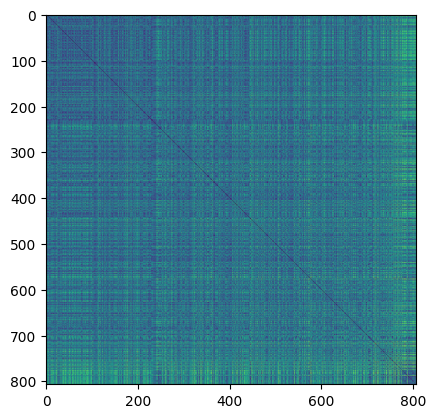

In [10]:
hcr_centroids = leftover_HCR_df[['hcr_x','hcr_y','hcr_z']].values # x,y,z order
# calculate pairwise distances

dist_matrix = distance_matrix(HCR_centroids_est, hcr_centroids)
final_matched_indices, final_matched_distances = one_to_one_matching(dist_matrix)

sort_order = np.argsort(final_matched_distances)
    
# Create matrix with matched sources (rows) and their assigned targets (columns)
sorted_sources = np.arange(len(final_matched_indices))[sort_order]
sorted_targets = final_matched_indices[sort_order]
sorted_dists = final_matched_distances[sort_order]

# Extract relevant distances for visualization
matched_dist_matrix = dist_matrix[np.ix_(sorted_sources, sorted_targets)]

plt.imshow(matched_dist_matrix)



In [16]:
# assign matching to matched_cells_df
new_matched_hcr_df = leftover_HCR_df.iloc[final_matched_indices].reset_index().copy().rename(columns={'index':'hcr_cell_id'})
new_matched_hcr_df['distance'] = final_matched_distances
new_matched_hcr_df['czstack_cell_id'] = leftover_czstack_ids
new_matched_hcr_df['czstack_x'] = leftover_czstack_df['czstack_x'].values
new_matched_hcr_df['czstack_y'] = leftover_czstack_df['czstack_y'].values
new_matched_hcr_df['czstack_z'] = leftover_czstack_df['czstack_z'].values
new_matched_hcr_df.sort_values(by='distance', inplace=True)
new_matched_hcr_df.head()

,hcr_cell_id,channel,sum,count,density,background,hcr_z,hcr_y,hcr_x,distance,czstack_cell_id,czstack_x,czstack_y,czstack_z
754,71804,488,3422202.0,7352,465.47906,95.0,1193,1002,1152,0.855517,869,181.305085,335.119622,417.158409
413,34663,488,8358343.0,12826,651.67180,99.0,798,1057,1108,0.930012,477,222.071380,271.644108,258.971044
467,44401,488,11187722.0,15614,716.51860,97.0,881,811,1185,1.067201,540,179.092537,447.852570,289.585406
513,51624,488,10772399.0,12915,834.09980,99.0,937,1282,1251,1.083851,596,102.521299,135.455094,319.556266
393,32851,488,7785806.0,4167,1868.44400,99.0,781,765,1234,1.126925,455,151.521111,478.721948,251.540510


In [18]:
save_fn = save_dir / f'{subject_id}_landmarks_matched_ext_iter{current_iter}.csv'
assert not save_fn.exists(), f'File {save_fn} exists already!'
landmarks_ext = pd.DataFrame()

landmarks_ext[0] = ['cz'+str(int(new_matched_hcr_df['czstack_cell_id'].iloc[i]))+'-hcr'+str(int(new_matched_hcr_df['hcr_cell_id'].iloc[i])) for i in range(len(new_matched_hcr_df))]

landmarks_ext[1] = False
landmarks_ext[2] = new_matched_hcr_df['czstack_x'].values
landmarks_ext[3] = new_matched_hcr_df['czstack_y'].values
landmarks_ext[4] = new_matched_hcr_df['czstack_z'].values
landmarks_ext[5] = new_matched_hcr_df['hcr_x'].values * scale_x
landmarks_ext[6] = new_matched_hcr_df['hcr_y'].values * scale_y
landmarks_ext[7] = new_matched_hcr_df['hcr_z'].values * scale_z

columns = np.arange(8)
landmarks.columns = columns
landmarks_ext = pd.concat([landmarks_ext, landmarks])

landmarks_ext.to_csv(save_fn, index=False, header=False)
landmarks_ext.head()

,0,1,2,3,4,5,6,7
0,cz869-hcr71804,False,181.305085,335.119622,417.158409,1136.487363,988.507238,1193.0
1,cz477-hcr34663,False,222.071380,271.644108,258.971044,1093.079860,1042.766617,798.0
2,cz540-hcr44401,False,179.092537,447.852570,289.585406,1169.042991,800.079212,881.0
3,cz596-hcr51624,False,102.521299,135.455094,319.556266,1234.154246,1264.736805,937.0
4,cz455-hcr32851,False,151.521111,478.721948,251.540510,1217.383165,754.698640,781.0


In [35]:
def _get_hcr_id(x):
    if x.startswith('cz'):
        return int(x.split('-hcr')[-1])
    else:
        return -1
landmarks_ext['hcr_id'] = landmarks_ext[0].apply(_get_hcr_id)

In [38]:
pd.DataFrame(landmarks_ext.query('hcr_id != -1').hcr_id.value_counts()).query('count == 2')

,count
hcr_id,
